# 002. Simulation Pipeline
- This runs the pre-contest pipeline, simulations, and optimizations
- Type: Pipeline
- Run Frequency: Daily (Contest)
- Created: 1/1/2025
- Updated: 8/20/2025

### Imports

In [1]:
from U01Imports import *
from U02Functions import *
from U03Classes import *
from U04Datasets import *
from U05Models import *

from A04Bullpens import *
from A05Rosters import *
from A06Weather import *
from A07Odds import *
from A08Projections import *
from A09DraftKings import *

from B01Matchups import *
from B02WFX import *
from B03ContestGuides import *

from C01Simulations import *
from C02Optimization import *

Using device: cuda


In [2]:
pause_code(start_time='2026-07-05T11:40:00', timezone='EST')

Time until 11:40AM. -455 hours, 54 minutes, and 6 seconds.


### Daily Contests

In [3]:
preferred_contest = "Four-Seamer"

try:
    daily_contest_df = pd.read_csv(os.path.join(baseball_path, "A09. DraftKings", "7. Subsets", f"Subset {todaysdate}.csv"))
    daily_contest_df = (daily_contest_df.assign(preferred=daily_contest_df['Name'].str.contains(preferred_contest, case=False, na=False)).sort_values(['contestDate', 'draftGroupId', 'preferred'], ascending=[True, False, False]).drop_duplicates('draftGroupId', keep='first').drop(columns='preferred'))

except:
    daily_contest_df = None

In [4]:
daily_contest_df[~daily_contest_df['Name'].str.contains("Turbo")][['contestKey', 'Name', 'Entry Fee', 'entries', 'date', 'contestTime', 'draftGroupId']].reset_index(drop=True)

,contestKey,Name,Entry Fee,entries,date,contestTime,draftGroupId
0,192658213,MLB $20K Four-Seamer [20 Entry Max],4.000000,5945,20260724,Fri 7:05PM,150913
1,192658267,MLB $35K Relay Throw [$10K to 1st] (Night),15.000000,2745,20260724,Fri 8:05PM,151271


### Settings

In [5]:
selected_contestKey = 192658213                        # If this is undefined, it will run for all games in game_df and all contests in contest_df
selected_contest_name, selected_entryFee = None, None  # Contest name or entry fee to subset contest_df for bulk runs

# start_date, end_date = "20250101", "20251231"          # Date range for game simulations
start_date, end_date = "20260101", "20261231"          # Date range for game simulations
start_date, end_date = todaysdate, todaysdate          # Date range for game simulations

### Games

Refresh game dataset

In [6]:
all_game_df = create_games(team_dict=team_dict, baseball_path=baseball_path, venue_map_df=venue_map_df, refresh_start_date=yesterdaysdate, refresh_end_date=todaysdate)

Select games

In [7]:
game_df = all_game_df[(all_game_df['date'].astype(str) >= start_date) & (all_game_df['date'].astype(str) <= end_date)].reset_index(drop=True)

### Refresh Data

In [8]:
start_time = time.time()

##### A04. Bullpens

In [9]:
historic = False

In [10]:
bullpens(date=todaysdate, team_map=team_map, historic=historic)

##### A05. Rosters

1. Batting Orders

In [11]:
df = game_df[game_df['date'] == todaysdate].reset_index(drop=True)

In [12]:
_ = Parallel(n_jobs=-1, verbose=0)(delayed(orders)(team_map, df, row) for row in range(len(df)))

2. Rosters

In [13]:
_ = Parallel(n_jobs=-1, verbose=0)(delayed(rosters)(team_map, df, row) for row in range(len(df)))

3. Projected Lineups - RotoGrinders

In [14]:
for _ in range(3):
    rotogrinders_lineups_df = scrape_rotogrinders_lineups()
    if not rotogrinders_lineups_df.empty:
        rotogrinders_lineups_df.to_csv(os.path.join(baseball_path, "A05. Rosters", "3. Projected Lineups - RotoGrinders", f"{todaysdate} Projected Lineups - RotoGrinders.csv"), index=False)
        break
    print("RotoGrinders lineup is empty.")
    time.sleep(5)

4. Projected Lineups - Baseball Monster

In [15]:
projected_batting_orders = pd.read_csv(rf"https://baseballmonster.com/Lineups.aspx?csv=1&d={todaysdate_dash}")
projected_batting_orders.to_csv(os.path.join(baseball_path, "A05. Rosters", "4. Projected Lineups - Baseball Monster", f"{todaysdate} Projected Lineups - Baseball Monster.csv"), index=False)

##### A06. Weather

In [16]:
df = game_df[(game_df['date'].astype(str) >= yesterdaysdate) & (game_df['date'].astype(str) <= todaysdate)].reset_index(drop=True)

1. Open Meteo

Setup the Open-Meteo API client **without** cache and with retry on error

In [17]:
base_session = requests.Session()
retry_session = retry(base_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

In [18]:
open_meteo_df = create_daily_weather_df(openmeteo, df[df['date'] == todaysdate])[game_columns + venue_columns + weather_columns + forecast_only_columns]
open_meteo_df.to_csv(os.path.join(baseball_path, "A06. Weather", "1. Open Meteo", f"Open Meteo {todaysdate}.csv"), index=False)

2. Kevin

In [19]:
try:
    kevin_df = kevin(todaysdate_dash)
    kevin_df.to_csv(os.path.join(baseball_path, "A06. Weather", "2. Kevin", f"Kevin {todaysdate}.csv"), index=False, encoding='iso-8859-1', errors='ignore')
except:
    print("Could not scrape Kevin weather data.")

##### A07. Odds

In [20]:
for date_dash in [todaysdate_dash]:
    # Create date compatibility with conventions
    date = date_dash.replace("-", "")
    try:
        # Scrape odds from Sportsbook Review
        odds_df = scrape_sportsbookreview(date_dash)
        odds_df['date'] = date
        # Write to CSV
        odds_df.to_csv(os.path.join(baseball_path, "A07. Odds", "1. Raw", f"Odds {date}.csv"), index=False)
        # Create DraftKings file
        draftkings_odds_df = select_odds(odds_df, team_dict, sportsbook="draftkings")
        # Write to CSV
        draftkings_odds_df.to_csv(os.path.join(baseball_path, "A07. Odds", "2. DraftKings", f"DraftKings Odds {date}.csv"), index=False)
        # Sleep to avoid hitting rate limit
        time.sleep(5)
    except:
        print(f"Sportsbook Review data unavailable for {date_dash}")

##### A08. Projections

1. DFF

1. Slates

In [21]:
dff_slates_df = pd.read_csv(os.path.join(baseball_path, "A08. Projections", "1. DFF", "1. Slates", f"DFF Slates {todaysdate}.csv"))

2. Projections

In [22]:
for code in dff_slates_df['URL']:
    try:
        # Scrape projections
        dff_projections_df = dff_projections(todaysdate, code)
        # To CSV
        dff_projections_df.to_csv(os.path.join(baseball_path, "A08. Projections", "1. DFF", "2. Projections", f"DFF Projections {code}.csv"), index=False)
    except KeyError as e:
        print("KeyError")

2. RotoWire

1. Slates

In [23]:
roto_slates_df = pd.read_csv(os.path.join(baseball_path, "A08. Projections", "2. RotoWire", "1. Slates", f"RotoWire Slates {todaysdate}.csv"))

2. Projections

In [24]:
try:
    for code in roto_slates_df['slateID']:
        # Scrape projections
        roto_projections_df = roto_projections(todaysdate, code)
        try:
            # To CSV
            roto_projections_df.to_csv(os.path.join(baseball_path, "A08. Projections", "2. RotoWire", "2. Projections", f"RotoWire Projections {code}.csv"), index=False)
        except:
            print(f"Can't scrape RotoWire projections for slate {code}.")
except:
    print("RotoWire projections unavailable.")

##### A09. DraftKings

Read in subset

In [25]:
subset_df = pd.read_csv(os.path.join(baseball_path, "A09. DraftKings", "7. Subsets", f'Subset {todaysdate}.csv'))

2. Draftables

In [26]:
# Loop over unique slates in subset of contests
for draftGroupId in list(subset_df['draftGroupId'].unique()):
    try:
        # Scrape draftables (Salaries)
        draftable_df = draftables(draftGroupId)
        # Write to CSV
        draftable_df.to_csv(os.path.join(baseball_path, "A09. DraftKings", "2. Draftables", f"Draftables {draftGroupId}.csv"), index=False, encoding='iso-8859-1')
        print(f"Saved {draftGroupId}")
    except:
        print(f"Didn't save {draftGroupId}")

del draftGroupId  # Just make sure you're not treating the latest as the draftGroupId of record going forward

Saved 151271
Saved 151265
Saved 150913


##### B01. Matchups

In [27]:
df = game_df[game_df['date'] == todaysdate].reset_index(drop=True)

In [28]:
%%time
create_all_matchups(df, baseball_path, team_dict, batter_inputs, pitcher_inputs, start_date=todaysdate, n_jobs=1)

CPU times: total: 1min 16s
Wall time: 1min 19s


[Parallel(n_jobs=1)]: Done  15 out of  15 | elapsed:    3.3s finished


##### B02. Weather Factors

Date(s): Today

In [29]:
# %%time
# is_main = False

# %run "C:\Users\James\Documents\MLB\Code\M01. Weather Factors.ipynb"

In [30]:
daily_wfx_df = get_daily_multipliers(todaysdate)
daily_wfx_df.to_csv(os.path.join(baseball_path, "B02. WFX", f"Park and Weather Factors {todaysdate}.csv"), index=False)

Sample: 50,000 (20,515 L, 29,485 R)
Latest rolling_carry_365d: 399.77
ParkConfig: 3,150 park-year rows, 263 parks
Crosswalk: 36 parks mapped to venue_id
Simulating 15 games


##### B03. Contest Guides

In [31]:
df = game_df[game_df['date'] == todaysdate].reset_index(drop=True)
year = todaysdate[:4]

In [32]:
# Read in contest subset
subset_df = pd.read_csv(os.path.join(baseball_path, 'A09. DraftKings', '7. Subsets', f'Subset {todaysdate}.csv'))

# Loop over contestKeys
for contestKey in subset_df['contestKey'].reset_index(drop=True):
    # print(contestKey)
    try:
        guide = contest_guide(df, subset_df=subset_df, contestKey=contestKey)
        if not guide.empty:
            guide.to_csv(os.path.join(baseball_path, "B03. Contest Guides", f"Contest Guide {contestKey}.csv"), index=False)
        else:
            print(f"Contest Guide {contestKey} is empty.")
    except FileNotFoundError as e:
        print(f"Draftables {contestKey}.csv not found.")

del contestKey  # Just make sure you're not treating the latest as the contestKey of record going forward

In [33]:
elapsed = time.time() - start_time
minutes, seconds = divmod(elapsed, 60)
print(f"Refreshing took {int(minutes)} minutes {seconds:.1f} seconds")

Refreshing took 2 minutes 50.0 seconds


### Contests

Read in contests

In [34]:
%%time
# Read in contests
contest_df = create_contests(start_date=start_date, end_date=end_date, name=selected_contest_name, entryFee=selected_entryFee, exclusions=['vs', 'Turbo', '@'])
contestKey = draftGroupId = contestDate = contestTime = None

# If there's a selected contest, just run that
if "selected_contestKey" in globals():
    # Take subset of contest_df
    contest_df = contest_df[contest_df['contestKey'] == selected_contestKey]
    # Extract contest info
    row = contest_df.iloc[0]
    contestKey, draftGroupId = row[['contestKey', 'draftGroupId']]
    _, contestDate, contestTime, _ = row['Game Info'].split()

# Merge on games
contest_df = contest_df.drop(columns=['game_type', 'game_num', 'date', 'away_score', 'home_score']).merge(game_df, on=['game_id'], how='left').sort_values('game_datetime', ascending=True)

print(f"Contest {contestKey} contains {contest_df.shape[0]} games.")

Contest 192658213 contains 10 games.
CPU times: total: 3.73 s
Wall time: 4.13 s


### Weather

In [35]:
red_list = []
orange_list = []

if start_date == end_date == todaysdate:
    kevin_df = pd.read_csv(os.path.join(baseball_path, "A06. Weather", "2. Kevin", f"Kevin {todaysdate}.csv"), dtype=str)

    kevin_df['game_num'] = kevin_df.groupby('home').cumcount() + 1  # Determine game number (for doubleheaders)

    red_list = kevin_df[kevin_df['weatherIndicator'].isin(['Red'])]['away'].unique().tolist() + kevin_df[kevin_df['weatherIndicator'].isin(['Red'])]['home'].unique().tolist()           # Red list (highest risk)
    orange_list = kevin_df[kevin_df['weatherIndicator'].isin(['Orange'])]['away'].unique().tolist() + kevin_df[kevin_df['weatherIndicator'].isin(['Orange'])]['home'].unique().tolist()  # Orange list (high risk)

    display(kevin_df[kevin_df['weatherNote'] != " "][['gameDate', 'game_num', 'away', 'home', 'weatherIndicator', 'weatherNote']].style.apply(color_rows, axis=1))

,gameDate,game_num,away,home,weatherIndicator,weatherNote
12,2026-07-24 08:10 PM,1,OAK,MIN,Green,"Winds are blowing at 15mph, but they are mostly right to left across the field, no in or out."
13,2026-07-24 08:15 PM,1,CIN,STL,Yellow,"YELLOW - The only game with any potential rain, but it all looks fairly light during gametime. My guess, they play on time, maybe deal with a light a sprinkle or two, and get a full 9 innings in without any delays. I am leaving this YELLOW for a chance of a heavier shower to cause a brief delay, but I don't currently expect it, and if radar looks good pregame I'll lower that risk even more."


### Openers

In [36]:
opener_list = []

if start_date == end_date == todaysdate and draftGroupId is not None:
    draftables_df = pd.read_csv(os.path.join(baseball_path, "A09. DraftKings", "2. Draftables", f"Draftables {draftGroupId}.csv"), encoding='iso-8859-1')
    opener_list = list(draftables_df.query('Salary <= 5500 and `Roster Position` == "P"')['Name'])

### C01. Simulations

##### Settings

In [37]:
wfx_type = "unadj"                                 # Adjust WFX values, recalibrating them after predicting. Options: "adj", "unadj"
debug = False                                    # Display debug info during simulation. Will only work when running in a single batch.
log = False                                      # Create CSV with PA model inputs and outputs
display_gambling_info = True                     # Display gambling payouts in print statements.
num_batches, batch_size = os.cpu_count(), 96     # Number of batches and batch size for parallel processing.
# num_batches, batch_size = os.cpu_count(), 1      # Number of batches and batch size for parallel processing.

print(f"Sims: {num_batches} x {batch_size} = {num_batches * batch_size}\nPA Model: {all_filename}")

Sims: 32 x 96 = 3072
PA Model: predict_all_512256_A_512x256_LowLR_Reg1e4_26652_20260722


##### Games

In [38]:
sim_game_df = game_df.copy()            # Use all games

if "selected_contestKey" in globals():  # Unless there's a contestKey selected
    sim_game_df = contest_df.copy()

##### Run

In [39]:
%%time
# -----------------------------------------------------------
# 1. SIM INFORMATION
# -----------------------------------------------------------
print(f"Simulating {sim_game_df.shape[0]} games {num_batches*batch_size} times.")

if log == True:
    os.remove(os.path.join(baseball_path, 'pa_summary_log.csv'))

# -----------------------------------------------------------
# 2. MAIN DATE LOOP
# -----------------------------------------------------------
for date in sim_game_df['date'].astype(str).unique():
    # Create folder for day's game simulation results
    os.makedirs(os.path.join(baseball_path, "C01. Simulations", "1. Game Sims", f"Matchups {date}"), exist_ok=True)

    ### Weather
    try:
        daily_weather_df = pd.read_csv(os.path.join(baseball_path, "B02. WFX", f"Park and Weather Factors {date}.csv"))
        for event in ['b1', 'b2', 'b3', 'hr', 'fo', 'go', 'lo', 'po']:
            daily_weather_df[f'{event}_wfx_l'] = daily_weather_df[f'{event}_wfx_{wfx_type}_l']
            daily_weather_df[f'{event}_wfx_r'] = daily_weather_df[f'{event}_wfx_{wfx_type}_r']
        for event in ['so', 'bb', 'hbp']:
            daily_weather_df[f'{event}_wfx_l'] = 1
            daily_weather_df[f'{event}_wfx_r'] = 1
        weather_lookup = {row['gamePk']: row for _, row in daily_weather_df.iterrows()}
    except Exception:
        print("Weather dataframe not created.")
        continue

    ### Projected Lineups (Today Only)
    projected_lineup_df = None
    if date == todaysdate:
        projected_lineup_df = pd.read_csv(os.path.join(baseball_path, "A05. Rosters", "3. Projected Lineups - RotoGrinders", f"{date} Projected Lineups - RotoGrinders.csv"))

    ### Gambling Odds
    odds_df = pd.read_csv(os.path.join(baseball_path, "A07. Odds", "2. DraftKings", f"DraftKings Odds {date}.csv"))
    odds_df['VisitorTeamShort'] = odds_df['VisitorTeamShort'].map(team_dict)
    odds_df['HomeTeamShort'] = odds_df['HomeTeamShort'].map(team_dict)
    odds_df['game_num'] = odds_df.groupby('HomeTeamShort').cumcount() + 1

    ### Daily Matchups
    daily_df = sim_game_df[sim_game_df['date'].astype(int) == int(date)].reset_index(drop=True)

    ### Loop over games
    for _, game_row in daily_df.iterrows():
        # Game info
        away_team, home_team = game_row['away_team'], game_row['home_team']
        game_id, game_num = game_row['game_id'], game_row['game_num']

        # Matchup
        matchup = {f.split()[1]: os.path.splitext(f)[0] for f in os.listdir(os.path.join(baseball_path, "B01. Matchups", f"Matchups {date}"))}.get(str(game_id))

        # Weather data
        game_weather_data = weather_lookup.get(game_id)

        ### Error Handling:
        # Missing Matchup
        if matchup is None:
            print("Matchup not found.")
            continue

        # Missing game weather data
        if game_weather_data is None:
            print("Game missing from weather dataframe.")
            continue

        # -------------------------------------------------------
        # 3. CREATE ORDERS AND PLAYER OBJECTS
        # -------------------------------------------------------
        # Create batting order dataframes
        # Prefer the API
        away_order_df = create_order_api(date, away_team, game_id)
        # But use RotoGrinders if that's not available
        if away_order_df['batting_order'].sum() != 45:
            away_order_df = create_order_rg(projected_lineup_df, away_team, game_num)

        home_order_df = create_order_api(date, home_team, game_id)
        if home_order_df['batting_order'].sum() != 45:
            home_order_df = create_order_rg(projected_lineup_df, home_team, game_num)

        # Read in matchups
        matchup_xl = pd.read_excel(os.path.join(baseball_path, "B01. Matchups", f"Matchups {date}", f"{matchup}.xlsx"), sheet_name=None)

        # Create player dataframes
        away_batter_df = matchup_xl["AwayBatters"].drop(columns="batting_order", errors="ignore")
        home_batter_df = matchup_xl["HomeBatters"].drop(columns="batting_order", errors="ignore")
        away_pitcher_df = matchup_xl["AwayPitchers"]
        home_pitcher_df = matchup_xl["HomePitchers"]

        # Create player objects
        AwayBatters, away_lineup_symbol = create_batter_objects(away_batter_df, away_order_df, scale_batter_stats, scale_batter_stats_steamer, impute_batter_stats)
        HomeBatters, home_lineup_symbol = create_batter_objects(home_batter_df, home_order_df, scale_batter_stats, scale_batter_stats_steamer, impute_batter_stats)
        AwayPitchers = create_pitcher_objects(away_pitcher_df, scale_pitcher_stats, scale_pitcher_stats_steamer, impute_pitcher_stats)
        HomePitchers = create_pitcher_objects(home_pitcher_df, scale_pitcher_stats, scale_pitcher_stats_steamer, impute_pitcher_stats)

        # Create park and game (with player) objects
        park_object = Park(**game_weather_data.to_dict())
        game_template = Scoreboard(AwayBatters, HomeBatters, AwayPitchers, HomePitchers, 9)

        # Create weather display
        # Speed
        speed = np.sqrt(park_object.meteo_x_vect**2 + park_object.meteo_y_vect**2)

        # Direction
        deg = (np.degrees(np.arctan2(park_object.meteo_y_vect, park_object.meteo_x_vect)) + 360) % 360
        arrows = ['→','↗','↑','↖','←','↙','↓','↘']
        idx = int((deg + 22.5) // 45) % 8

        wind_display = f"{round(speed, 1)} mph {arrows[idx]}"

        ### Kevin
        weather_indicator = 'DEFAULT'
        if "kevin_df" in globals():
            weather_indicator = kevin_df[(kevin_df['home'] == home_team) & (kevin_df['game_num'] == game_num)]['weatherIndicator'].iloc[0] if not kevin_df[(kevin_df['home'] == home_team) & (kevin_df['game_num'] == game_num)].empty else None

        color_map = {
            "Green": "\033[92m",
            "Yellow": "\033[93m",
            "Orange": "\033[38;5;208m",
            "Red": "\033[91m"
        }

        RESET = "\033[0m"

        color = color_map.get(weather_indicator, "")

        print()
        print(f"{color}{date} {matchup} {wind_display} {round(park_object.temperature_2m, 1)}°")# {park_object.weather}{RESET}")

        # -------------------------------------------------------
        # 4. SIMULATE GAMES
        # -------------------------------------------------------
        start_time = time.time()

        # Simulate games in parallel batches
        game_list_batches = Parallel(n_jobs=num_batches, backend='loky')(delayed(sim_game_batch)(game_template, opener_list, park_object=park_object, models=models_dict, innings=9, debug=debug, log=log, batch_size=batch_size)
                                                                         for _ in range(num_batches))

        # Record sim time
        sim_time = time.time()-start_time

        # Flatten the list of lists
        game_list = [g for batch in game_list_batches for g in batch]

        # -------------------------------------------------------
        # 5. SAVE RESULTS
        # -------------------------------------------------------
        start_time = time.time()

        # Ensure a Player Sims folder exists and is empty
        shutil.rmtree(os.path.join(baseball_path, "C01. Simulations", "2. Player Sims", f"Matchups {date}", matchup), ignore_errors=True)
        os.makedirs(os.path.join(baseball_path, "C01. Simulations", "2. Player Sims", f"Matchups {date}", matchup), exist_ok=True)

        # Create lists to fill with sim data
        game_score_rows = []

        all_batter_rows = []
        all_pitcher_rows = []

        ### Loop over sim results
        for sim_id, game_object in enumerate(game_list):
            ### Scores
            game_score_rows.append({
                "game_id": game_id,
                "sim": sim_id,
                "away_score": game_object.away_score,
                "home_score": game_object.home_score
            })

            ### Players
            # Keep only selected attributes
            for batter in game_object.away_batters + game_object.home_batters:
                batter.keep_selected_attributes()
            for pitcher in game_object.away_pitchers + game_object.home_pitchers:
                pitcher.keep_selected_attributes()
            game_object.keep_selected_attributes()

            # Create game_scores_df from score rows
            game_scores_df = pd.DataFrame(game_score_rows)

            # Append player rows to create player dataframes
            def append_rows(objects, team, all_rows):
                for obj in objects:
                    row = vars(obj).copy()
                    row.update({
                        "team": team,
                        "away_score": game_object.away_score,
                        "home_score": game_object.home_score,
                        "sim": sim_id,
                        "game_id": game_id
                    })
                    all_rows.append(row)

            # Batters
            append_rows(game_object.away_batters, "away", all_batter_rows)
            append_rows(game_object.home_batters, "home", all_batter_rows)

            # Pitchers
            append_rows(game_object.away_pitchers, "away", all_pitcher_rows)
            append_rows(game_object.home_pitchers, "home", all_pitcher_rows)

        # Create dataframes
        batters_df = pd.DataFrame(all_batter_rows)
        pitchers_df = pd.DataFrame(all_pitcher_rows)

        # Write to CSV
        game_scores_df.to_csv(os.path.join(baseball_path, "C01. Simulations", "1. Game Sims", f"Matchups {date}", f"game_{game_id}.csv"), index=False)

        batters_df.to_csv(os.path.join(baseball_path, "C01. Simulations", "2. Player Sims", f"Matchups {date}", matchup, "batters.csv"), index=False)
        pitchers_df.to_csv(os.path.join(baseball_path, "C01. Simulations", "2. Player Sims", f"Matchups {date}", matchup, "pitchers.csv"), index=False)

        print(f"Time: {sim_time: .2f} simming, {time.time() - start_time:.2f} saving.")
        display_results(away_team, away_lineup_symbol, AwayPitchers[0].fullName, home_team, home_lineup_symbol, HomePitchers[0].fullName, game_num, odds_df, game_scores_df, display_gambling_info)

Simulating 10 games 3072 times.

20260724 ATL@BAL 824812 1905 6.1 mph ← 81.0°
Time:  14.16 simming, 6.60 saving.
ATL*   4.61 (53.16%) | ML   1.06 ( -101) | SPR  -3.0   0.38 ( -291) | OVR   9.0   0.86 ( -110) | SP Grant Holmes
BAL*   4.24 (46.84%) | ML   0.86 ( -119) | SPR   3.0   0.93 ( -457) | UND   9.0   1.06 ( -110) | SP Albert Suarez

20260724 LAD@NYM 823601 1910 8.9 mph ↖ 76.4°
Time:  13.48 simming, 7.02 saving.
LAD*   4.55 (47.53%) | ML   0.82 ( -136) | SPR  -1.5   0.79 (  119) | OVR   9.0   0.89 ( -110) | SP Roki Sasaki
NYM*   4.50 (52.47%) | ML   1.12 (  113) | SPR   1.5   1.08 ( -143) | UND   9.0   1.03 ( -110) | SP Sean Manaea

20260724 CLE@TBR 822952 1910 0.0 mph → 70.0°
Time:  12.64 simming, 6.53 saving.
CLE*   3.90 (46.29%) | ML   1.01 (  118) | SPR   1.5   0.97 ( -182) | OVR   7.5   0.94 ( -106) | SP Joey Cantillo
TBR*   3.97 (53.71%) | ML   0.92 ( -142) | SPR  -1.5   0.93 (  150) | UND   7.5   0.97 ( -114) | SP Shane McClanahan

20260724 SDP@MIA 823843 1910 0.0 mph → 70.

### C02. Optimization

Stop here if no contest is selected

In [40]:
if "selected_contestKey" not in globals():
    raise SystemExit

##### Download entry file for draftGroupId

In [41]:
display(Javascript(f"window.open('https://www.draftkings.com/bulkentryedit/getentriescsv?draftGroupId={draftGroupId}', '_blank');"))
time.sleep(2)
clear_output()

Determine number of portfolio lineups

In [42]:
entry_df = pd.read_csv(os.path.join(download_path, max([f for f in os.listdir(download_path) if f.startswith("DKEntries")], key=lambda x: os.path.getctime(os.path.join(download_path, x)))), usecols=['Entry ID','Contest Name','Contest ID','Entry Fee'])
num_portfolio_lineups = entry_df.dropna().shape[0]

##### 1. Players

In [43]:
_ = Parallel(n_jobs=-1)(delayed(create_player_file)(row['contestKey'],                                                                 # DraftKings contest number
                                                    contest_df[contest_df['contestKey'] == row['contestKey']].reset_index(drop=True),  # Contest dataframe
                                                    row['draftGroupId'],                                                               # DraftKings draftGroupId
                                                    row['roto_slate'],                                                                 # RotoWire slateID
                                                    max_exposure_pitchers=0.7,                                                         # Maximum ownership for pitchers (Currently overridden in C02Optimization.py)
                                                    max_exposure_batters=0.5,                                                          # Maximum ownership for batters (Currently overridden in C02Optimization.py)
                                                    projections='robot',                                                               # Point projection source. Options: 'robot', 'roto'
                                                    rostership='roto',                                                                 # Rostership source. Options: 'roto' ('robot' to come)
                                                    ownership_spread=0.25,                                                             # Multiplier for minimum and maximum player ownership thresholds from 'rostership'
                                                    write_file=True)                                                                   # Write to CSV
                                                    for _, row in contest_df.drop_duplicates(subset=['contestKey'])[['contestKey','draftGroupId','roto_slate']].iterrows())

In [44]:
excel_button(os.path.join(baseball_path, "C02. Optimization", "1. Players", f"Players {contestKey}.csv"))

Button(description='Open Players 192658213.csv in Excel 📊', style=ButtonStyle())

##### 2. Lineups

In [45]:
%%time
stack_dictionary = {          # Stacking methodologies to generate and share of num_optimizer_lineups to make
    (5,2,1):   0.20,
    (5,3):     0.20,
    (5,1,1,1): 0.20,
    (4,3,1):   0.20,
    (4,4):     0.20
}

fallback_rules = [                               # Parameters and fallback options
    {"min_starters": 10,                         # Main
     "min_projection": 5,
     "excluded_teams": red_list + orange_list},
    {"min_starters": 0,                          # Fallback
     "min_projection": 0,
     "excluded_teams": red_list}
    ]

_ = Parallel(n_jobs=-2, backend='loky')(delayed(run_parallel_optimizers)(contestKey=contestKey,              # DraftKings contest number
                                                                         stack_dictionary=stack_dictionary,  # Stacking methodologies to generate and share of num_optimizer_lineups to make
                                                                         fallback_rules=fallback_rules,      # Lineup parameters and fallback options
                                                                         num_optimizer_lineups=1000,         # Number of lineups to generate
                                                                         fallback="failure")                 # Condition for running with fallback parameters
                                                                         for contestKey in contest_df['contestKey'].unique())

CPU times: total: 297 ms
Wall time: 4min 17s


##### 3. Field Lineups

In [46]:
%%time
stack_share_dict = {
    '5-2-1':   0.365811,
    '5-3':     0.283465,
    '5-1-1-1': 0.146111,
    '4-3-1':   0.116435,
    '4-2-1-1': 0.088178,
}
_ = create_all_field_lineups(contestKeys=contest_df['contestKey'].unique().tolist(),
                             contest_df=contest_df,
                             num_lineups=2000,                                   # Number of field lineups to keep
                             max_salary=50000,                                   # Maximum lineup salary
                             stack_share_dict=stack_share_dict,                  # Dictionary containing rates for stack ownership
                             pitcher_exp=1.0,                                    # Exponent to weight pitchers (>1: overweight, <1: underweight)
                             team_exp=1.0,                                       # Exponent to weight teams (>1: overweight, <1: underweight)
                             max_attempts=10000,                                 # Maximum attempts to generate lineups
                             player_noise=0.0,                                   # Player ownership noise factor
                             team_noise=0.0,                                     # Team ownership noise factor
                             pitcher_pattern_weights=[0.2, 0.2, 0.2, 0.2, 0.2],  # Share of patterns used to determine which order to fill in positions
                             calibrate=True,                                     # Generate additional field lineups and prune until field looks as prefered
                             calibrate_oversample=5,                             # Multiplier to determine number of field lineups to generate before pruning
                             write_file=True,                                    # Write to CSV
                             n_jobs=-2)                                          # Number of joblib jobs

Calibration enabled: generating 10000 lineups, selecting 2000
[192658213] 10000 lineups in 25983 attempts. Rejections — stack: 1325, salary: 14126, pitchers: 532
[192658213] Calibrating 10000 → 2000 lineups...
CPU times: total: 1min 2s
Wall time: 1min 2s


=== PROJECTED vs ACTUAL FIELD OWNERSHIP (sorted by projected rostership) ===
Player                              Pos     Salary  Projected   Actual    Error
--------------------------------------------------------------------------------
Shane McClanahan(43672268)          P        9,000      25.5%    26.7%    +1.2%
Bryce Miller(43672266)              P       10,000      21.1%    23.2%    +2.2%
Logan Webb(43672267)                P        9,700      20.6%    22.4%    +1.9%
Byron Buxton(43672291)              OF       6,000      19.4%    20.8%    +1.4%
Luis Arraez(43672332)               2B       4,500      18.6%    18.6%    -0.1%
Tommy Edman(43672321)               2B/3B    4,700      16.0%    16.4%    +0.5%
Kyle Tucker(43672331)               OF       4,500      15.7%    16.3%    +0.6%
Mookie Betts(43672312)              SS       5,000      15.6%    16.3%    +0.7%
Ryan Jeffers(43672303)              C        5,200      13.6%    14.8%    +1.2%
Teoscar Hernandez(43672351)         OF    

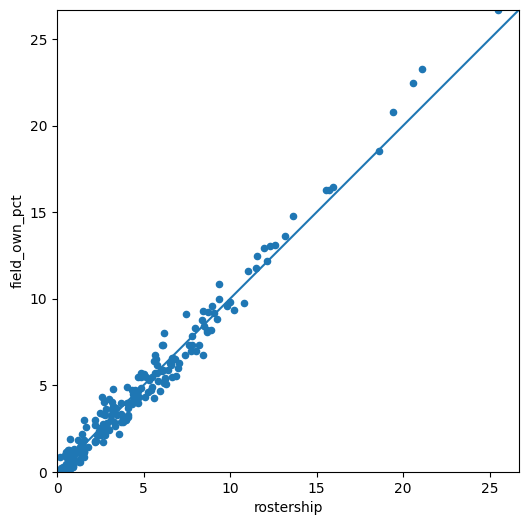

In [47]:
_,_ = analyze_ownership(contestKey)

##### 4. Portfolio Lineups

In [48]:
%%time
if "num_portfolio_lineups" not in globals():
    num_portfolio_lineups = 20

_ = Parallel(n_jobs=-1, backend="loky")(delayed(choose_portfolio)(contestKey,                            # DraftKings contest number
                                                                  portfolio_size=num_portfolio_lineups,  # Number of lineups to include in final portfolio
                                                                  n_iterations=500,                      # Number of attempts to swap out lineups to optimize for metric
                                                                  swap_size=2,                           # Number of lineups to swap out during each iteration
                                                                  random_seed=1,                         # Random seed
                                                                  optimize_metric='Top_1pct_any',        # Metric used to choose best lineups. Options: 'EV', 'Top_1pct_rate', 'Top_5pct_rate'
                                                                  write_file=True)                       # Write to CSV
                                        for contestKey in contest_df['contestKey'].unique())

CPU times: total: 78.1 ms
Wall time: 9.91 s


##### 5. Lineups Ranked

In [49]:
%%time
_ = Parallel(n_jobs=-1, backend="loky")(delayed(rank_lineups)(contestKey,                                 # DraftKings contest number
                                                              pareto_set=['Plus3', 'batter rostership'],  # Pareto set metrics
                                                              sense_list=['Max', 'Min'],                  # Pareto set rank preferences
                                                              sort_by=['pareto', 'Plus3'],                # Lineup ranking method
                                                              ascending_list=[False, False],              # Lineup ranking direction
                                                              lineup_type="Portfolio",                    # Lineups to rank. Options: "Optimizer", "Portfolio"
                                                              write_file=True)                            # Write to CSV
                                        for contestKey in contest_df['contestKey'].unique())

CPU times: total: 46.9 ms
Wall time: 28.6 s


In [50]:
excel_button(os.path.join(baseball_path, "C02. Optimization", "5. Lineups Ranked", f"Lineups Ranked {contestKey}.csv"))

Button(description='Open Lineups Ranked 192658213.csv in Excel 📊', style=ButtonStyle())

##### 6. Uploads

In [51]:
create_upload_file(contestKey, sort_by='Plus3').head(50).to_csv(os.path.join(baseball_path, "C02. Optimization", "6. Uploads", f"Upload {contestKey}.csv"), index=False)

##### 7. Entries

In [52]:
create_entry_file(draftGroupId, contestKey).to_csv(os.path.join(baseball_path, "C02. Optimization", "7. Entries", f"Entries {draftGroupId}.csv"), index=False, encoding='iso-8859-1')

##### Upload

In [53]:
upload_entries(draftGroupId)

##### Email

In [54]:
# email_upload_file(draftGroupId, contestKey, contestTime)